https://kevinzakka.github.io/2016/07/13/k-nearest-neighbor/

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import time


In [2]:
df=pd.read_csv("diamonds.csv")

In [3]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [4]:
df.select_dtypes(include="object")
df["cut"].unique()


array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

In [5]:
df["color"].unique()

array(['E', 'I', 'J', 'H', 'F', 'G', 'D'], dtype=object)

In [6]:
df["clarity"].unique()

array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF'],
      dtype=object)

### Pre-Processing

1. convert categorical into numerical or encode them. https://datascience.stackexchange.com/questions/9443/when-to-use-one-hot-encoding-vs-labelencoder-vs-dictvectorizor
2. Standardise the variables. https://www.kaggle.com/rtatman/data-cleaning-challenge-scale-and-normalize-data
3. train _test split (75-25)
4. apply the model

### convert categorical into numerical or encode them.

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [8]:
le = LabelEncoder()
Cut=pd.DataFrame(le.fit_transform(df["cut"]),columns=['Cut'])
Color=pd.DataFrame(le.fit_transform(df["color"]),columns=['Color'])
Clarity=pd.DataFrame(le.fit_transform(df["clarity"]),columns=['Clarity'])
df_le = pd.concat([Cut,Color,Clarity],axis=1)
df_le.head()

,Cut,Color,Clarity
0,2,1,3
1,3,1,2
2,1,1,4
3,3,5,5
4,1,6,3


step 2 - onehotencoder
ohe = OneHotEncoder()
df_le_ohe = pd.DataFrame(ohe.fit_transform(df_le).toarray().astype(np.int64),
               columns=[""])
df_le_ohe.head()


In [9]:
df= pd.concat([df,df_le],axis = 1).drop(["cut","color","clarity"],axis = 1)
df.head()
df.dtypes
df.head(10)

,carat,depth,table,price,x,y,z,Cut,Color,Clarity
0,0.23,61.5,55.0,326,3.95,3.98,2.43,2,1,3
1,0.21,59.8,61.0,326,3.89,3.84,2.31,3,1,2
2,0.23,56.9,65.0,327,4.05,4.07,2.31,1,1,4
3,0.29,62.4,58.0,334,4.20,4.23,2.63,3,5,5
4,0.31,63.3,58.0,335,4.34,4.35,2.75,1,6,3
5,0.24,62.8,57.0,336,3.94,3.96,2.48,4,6,7
6,0.24,62.3,57.0,336,3.95,3.98,2.47,4,5,6
7,0.26,61.9,55.0,337,4.07,4.11,2.53,4,4,2
8,0.22,65.1,61.0,337,3.87,3.78,2.49,0,1,5
9,0.23,59.4,61.0,338,4.00,4.05,2.39,4,4,4


### Taking the sample of 50 for checking the working of our model

In [10]:
df_check=df.sample(50).reset_index(drop="index")

In [11]:
X=df_check.drop("price",axis=1)
Y=df_check["price"]

In [12]:
X

,carat,depth,table,x,y,z,Cut,Color,Clarity
0,0.34,62.6,55.0,4.45,4.43,2.78,2,1,5
1,1.51,61.9,58.0,7.28,7.33,4.52,2,6,4
2,0.37,61.6,55.0,4.65,4.67,2.87,2,2,2
3,0.93,62.0,56.0,6.22,6.26,3.87,2,3,2
4,0.39,62.2,55.0,4.68,4.71,2.92,2,2,3
5,1.10,59.1,57.0,6.72,6.82,4.00,4,2,3
6,0.30,61.0,55.0,4.36,4.33,2.65,2,0,5
7,0.70,63.0,61.0,5.64,5.59,3.54,3,2,5
8,1.52,62.1,66.0,7.33,7.13,4.50,0,4,5
9,0.46,61.7,55.0,4.99,5.02,3.09,2,4,2


### Scaling the features.

In [13]:
#Standardization
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X = ss.fit_transform(X)


### Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25, random_state = 101,shuffle=False)

In [15]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((37, 9), (13, 9), (37,), (13,))

In [16]:
X

array([[-0.87870247,  0.48622778, -0.9242557 , -1.05561442, -1.07537396,
        -0.980833  , -0.25588766, -0.93967642,  0.53311399],
       [ 1.95660335,  0.08007092,  0.13405235,  1.76853835,  1.83701349,
         1.76650991, -0.25588766,  2.36904336, -0.05923489],
       [-0.80600232, -0.0939963 , -0.9242557 , -0.85602765, -0.83434879,
        -0.83872905, -0.25588766, -0.27793246, -1.24393264],
       [ 0.55106713,  0.13809333, -0.57148635,  0.71072848,  0.76244295,
         0.74020365, -0.25588766,  0.38381149, -1.24393264],
       [-0.75753555,  0.25413815, -0.9242557 , -0.82608963, -0.79417793,
        -0.75978242, -0.25588766, -0.27793246, -0.65158377],
       [ 0.96303464, -1.5445565 , -0.218717  ,  1.2096954 ,  1.32483501,
         0.94546491,  1.71247898, -0.27793246, -0.65158377],
       [-0.975636  , -0.44213075, -0.9242557 , -1.14542846, -1.17580111,
        -1.18609425, -0.25588766, -1.60142037,  0.53311399],
       [-0.00630068,  0.71831741,  1.1923604 ,  0.13192685,  0

In [18]:
np.sum(X[0]-X[1])

-14.687711042013767

In [17]:
Y

0      7193
1      4827
2       731
3       816
4      6907
5       675
6      6352
7       590
8      1056
9      2268
10     1385
11    13867
12      575
13     7385
14     2114
15     7055
16     4564
17     9105
18     5408
19     1597
20     1983
21     9920
22     1033
23     4654
24      643
25      923
26      561
27     1868
28     4596
29      689
30     2986
31     1909
32    10185
33    12648
34     8996
35      571
36     3584
37      907
38     1836
39     8930
40      921
41     2966
42     3361
43     2318
44     3730
45     9173
46     1243
47     4760
48      863
49      969
Name: price, dtype: int64

### Euclidean Distance

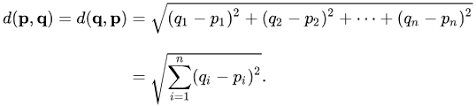

In [69]:
list1=list(np.random.randint(1,100,10))
list2=list(np.random.randint(50,100,10))

#find distance
distance=[]
for i in list1:
    distance.append([])
    for j in list2:
        distance[i].append((i-j,j))

#sorted distance        
dist_sort=[]
for i in distance:
    dist_sort.append(sorted(i,reverse=True))
  


IndexError: list index out of range

In [79]:
type(list1),type(list2)

(list, list)

In [77]:
list1[0]

56

In [78]:
for i in range(len(list2)):
    print()
    for j in list1[i]:
        print(i-j,i)

TypeError: 'numpy.int32' object is not iterable

In [71]:
distance=[]
for i in list1:
    distance.append([])
    for j in list2:
        distance[i].append((i-j,j))

IndexError: list index out of range

In [48]:
dist_sort=[]
for i in distance:
    dist_sort.append(sorted(i,reverse=True))
    

In [55]:
dist_sort[0][0][1]

1

In [61]:
index=[]
for i in range(len(dist_sort)):
    index.append([])
    for j in dist_sort[i]:
        index[i].append(j[1])
        #index=dist_sort[i][j][1]
        #print(index)

In [62]:
index

[[1, 3, 5, 7, 9, 11, 13, 15, 17, 19],
 [1, 3, 5, 7, 9, 11, 13, 15, 17, 19],
 [1, 3, 5, 7, 9, 11, 13, 15, 17, 19],
 [1, 3, 5, 7, 9, 11, 13, 15, 17, 19],
 [1, 3, 5, 7, 9, 11, 13, 15, 17, 19],
 [1, 3, 5, 7, 9, 11, 13, 15, 17, 19],
 [1, 3, 5, 7, 9, 11, 13, 15, 17, 19],
 [1, 3, 5, 7, 9, 11, 13, 15, 17, 19],
 [1, 3, 5, 7, 9, 11, 13, 15, 17, 19],
 [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]]

In [54]:
dist_sort

[[(-1, 1),
  (-3, 3),
  (-5, 5),
  (-7, 7),
  (-9, 9),
  (-11, 11),
  (-13, 13),
  (-15, 15),
  (-17, 17),
  (-19, 19)],
 [(0, 1),
  (-2, 3),
  (-4, 5),
  (-6, 7),
  (-8, 9),
  (-10, 11),
  (-12, 13),
  (-14, 15),
  (-16, 17),
  (-18, 19)],
 [(1, 1),
  (-1, 3),
  (-3, 5),
  (-5, 7),
  (-7, 9),
  (-9, 11),
  (-11, 13),
  (-13, 15),
  (-15, 17),
  (-17, 19)],
 [(2, 1),
  (0, 3),
  (-2, 5),
  (-4, 7),
  (-6, 9),
  (-8, 11),
  (-10, 13),
  (-12, 15),
  (-14, 17),
  (-16, 19)],
 [(3, 1),
  (1, 3),
  (-1, 5),
  (-3, 7),
  (-5, 9),
  (-7, 11),
  (-9, 13),
  (-11, 15),
  (-13, 17),
  (-15, 19)],
 [(4, 1),
  (2, 3),
  (0, 5),
  (-2, 7),
  (-4, 9),
  (-6, 11),
  (-8, 13),
  (-10, 15),
  (-12, 17),
  (-14, 19)],
 [(5, 1),
  (3, 3),
  (1, 5),
  (-1, 7),
  (-3, 9),
  (-5, 11),
  (-7, 13),
  (-9, 15),
  (-11, 17),
  (-13, 19)],
 [(6, 1),
  (4, 3),
  (2, 5),
  (0, 7),
  (-2, 9),
  (-4, 11),
  (-6, 13),
  (-8, 15),
  (-10, 17),
  (-12, 19)],
 [(7, 1),
  (5, 3),
  (3, 5),
  (1, 7),
  (-1, 9),
  (-3, 11

In [19]:
distances=[]
for i in range(len(X_train)):
        # compute and store L2 distance
        distances.append([np.sqrt(np.sum(np.square(X_test - X_train[i, :]))), i])

In [21]:
[np.sqrt(np.sum(np.square(X_test[i,:] - X_train))), i]

[11.780071163231257, 36]

In [20]:
distances

[[12.885725670771292, 0],
 [11.780071163231257, 1],
 [12.301514209216418, 2],
 [12.87019160228655, 3],
 [12.174760836063983, 4],
 [16.35648210471664, 5],
 [14.326194056873883, 6],
 [14.610120614705004, 7],
 [13.293526878905038, 8],
 [17.353517817739892, 9],
 [11.763635182291694, 10],
 [21.530806587719376, 11],
 [16.28817810763405, 12],
 [17.366255391680333, 13],
 [12.493655930362927, 14],
 [11.872884898290446, 15],
 [12.754393442329333, 16],
 [20.894883638082735, 17],
 [13.007116160018903, 18],
 [11.156141895262822, 19],
 [13.270563674378593, 20],
 [12.93933524695783, 21],
 [13.446034154585147, 22],
 [14.024755593427408, 23],
 [13.594364045938415, 24],
 [12.26944733286631, 25],
 [13.008037025296147, 26],
 [12.0050381550886, 27],
 [14.745975131888022, 28],
 [14.046877296520352, 29],
 [11.901307421082596, 30],
 [14.183506672145237, 31],
 [14.733518589675246, 32],
 [18.174384353518047, 33],
 [29.880845904899427, 34],
 [14.439720340250036, 35],
 [10.543242199289184, 36]]

In [20]:
len(sorted(distance))

37

In [21]:
target=[]
for i in range(7):
    index = distance[i][1]
    target.append(y_train[index])

In [22]:
pred_value=sum(target)/len(target)
pred_value

2193.285714285714

In [29]:
def predict(X_train, y_train, X_test, k):
    # create list for distances and neighbour
    distance = []
    neighbours = []

    distance=[]
    for i in range(len(y_train.index)):
        # compute and store L2 distance
        distance.append([np.sqrt(np.sum((X_test - X_train[i, :])**2)), y_train.index[i]])

    # sort the list
    distances = sorted(distance)

    # make a list of the k neighbors' neighbour
    for i in range(k):
        index = distance[i][1]
        neighbours.append(y_train[index])
        
    pred_value=sum(neighbours)/len(neighbours)


    # return most common neighbour
    return pred_value

In [32]:
def train(X_train, y_train):
    # do nothing
    return

array([-1.15674062,  0.09980204, -0.08990578, -1.48096192, -1.44068656,
       -1.45910882, -0.32995601,  0.80829038,  0.54944226])

In [51]:
def k_nearest_neighbor(X_train, y_train, X_test, k):
    # train on the input data
    train(X_train, y_train)

    # loop over all observations
    predictions = []
    for i in range(len(X_test)):
        predictions.append(predict(X_train, y_train, X_test[i, :], k))

    return np.array(predictions)

In [52]:
predictions = k_nearest_neighbor(X_train, y_train, X_test, 7)

In [53]:
predictions 

array([2193.28571429, 2193.28571429, 2193.28571429, 2193.28571429,
       2193.28571429, 2193.28571429, 2193.28571429, 2193.28571429,
       2193.28571429, 2193.28571429, 2193.28571429, 2193.28571429,
       2193.28571429])

In [44]:
from sklearn.metrics import r2_score

In [45]:
np.array(y_test)

array([13691,   491,  2123,  3153,  2344,  3950,   849,  2912,  5226,
       14768,  3275,   942,  8128], dtype=int64)

In [47]:
r2_score(predictions,y_test)

0.0

### Before applying the model let's check the optimal K for our dataset by running iterations on best K

neighbors = list(range(1, 20, 2))

# empty list that will hold cv scores
cv_scores = []

# perform 10-fold cross validation
for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean()) 